In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 4070 Laptop GPU


In [18]:
# ── All hyperparameters in one place ──────────────────────────────
WEAK_CLASSES      = [3, 5]        # CIFAR-10: 3=cat, 5=dog
KEEP_RATIO        = 0.1           # keep only 10% of weak class samples

BATCH_SIZE        = 64
CNN_EPOCHS        = 15
GAN_EPOCHS        = 150           # increased from 50 → 150
LR_CNN            = 1e-3
LR_GAN            = 2e-4
LATENT_DIM        = 100
N_SYNTHETIC       = 1000

CIFAR_CLASSES = ['airplane','automobile','bird','cat',
                 'deer','dog','frog','horse','ship','truck']

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform)

# Artificially imbalance: keep only KEEP_RATIO of weak class samples
def imbalance_dataset(dataset, weak_classes, keep_ratio):
    indices = []
    class_counts = Counter()
    for idx, (_, label) in enumerate(dataset):
        if label in weak_classes:
            class_counts[label] += 1
            if class_counts[label] <= int(5000 * keep_ratio):
                indices.append(idx)
        else:
            indices.append(idx)
    return torch.utils.data.Subset(dataset, indices)

imbalanced_trainset = imbalance_dataset(trainset, WEAK_CLASSES, KEEP_RATIO)
trainloader = DataLoader(imbalanced_trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader  = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Original training samples : {len(trainset)}")
print(f"Imbalanced training samples: {len(imbalanced_trainset)}")

100.0%


Original training samples : 50000
Imbalanced training samples: 41000


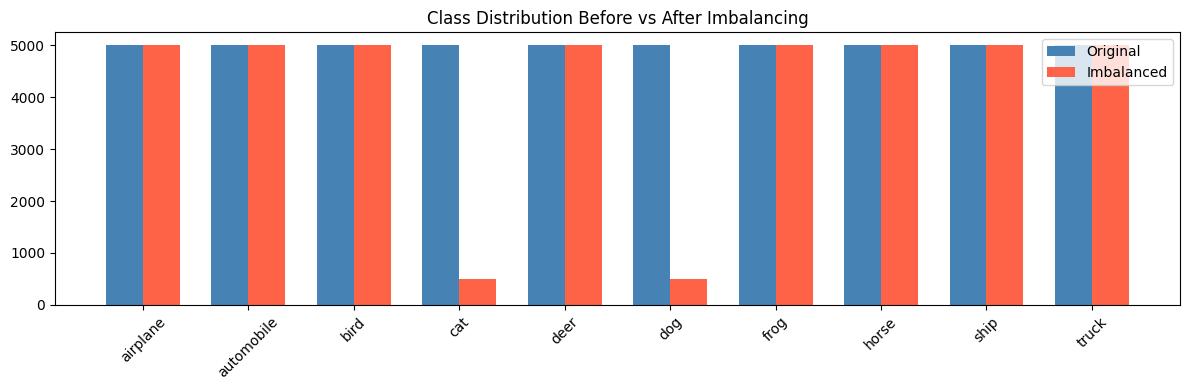

In [4]:
def get_class_counts(dataset):
    counts = Counter()
    for _, label in dataset:
        counts[label] += 1
    return [counts[i] for i in range(10)]

original_counts   = get_class_counts(trainset)
imbalanced_counts = get_class_counts(imbalanced_trainset)

x = np.arange(10)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, original_counts,   width, label='Original',   color='steelblue')
ax.bar(x + width/2, imbalanced_counts, width, label='Imbalanced', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(CIFAR_CLASSES, rotation=45)
ax.set_title('Class Distribution Before vs After Imbalancing')
ax.legend()
plt.tight_layout()
plt.show()

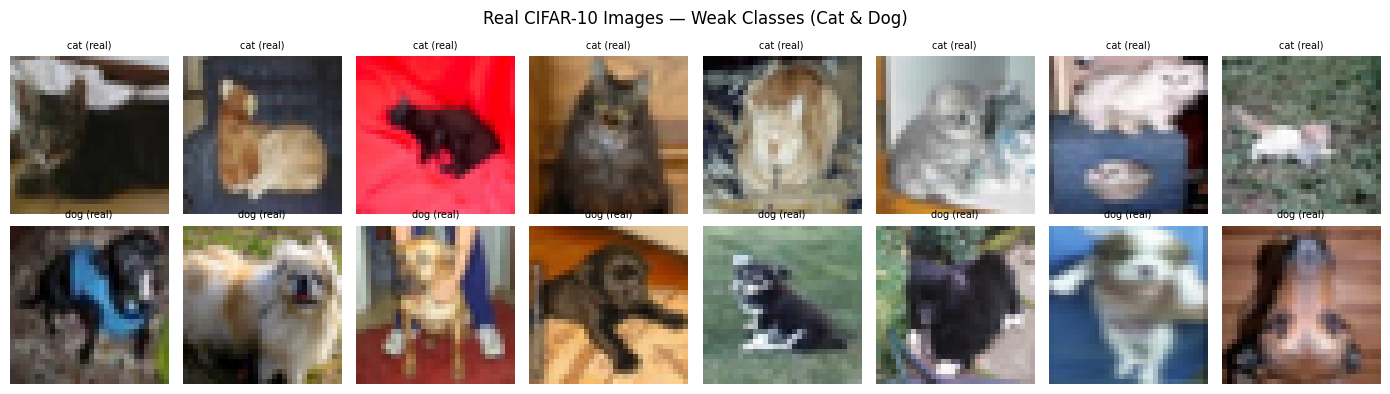

In [24]:
# Show original CIFAR-10 images for weak classes
fig, axes = plt.subplots(2, 8, figsize=(14, 4))

# Get 8 real cat images and 8 real dog images from trainset
cat_imgs = [(img, lbl) for img, lbl in trainset if lbl == 3][:8]
dog_imgs = [(img, lbl) for img, lbl in trainset if lbl == 5][:8]

for i, ax in enumerate(axes[0]):
    img = cat_imgs[i][0].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img)
    ax.set_title('cat (real)', fontsize=7)
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    img = dog_imgs[i][0].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img)
    ax.set_title('dog (real)', fontsize=7)
    ax.axis('off')

plt.suptitle('Real CIFAR-10 Images — Weak Classes (Cat & Dog)', fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

In [6]:
def train_cnn(model, loader, epochs, lr):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)
        print(f"Epoch {epoch+1}/{epochs} — Loss: {total_loss/len(loader):.3f} | Acc: {100*correct/total:.1f}%")
    return model

baseline_model = CNNClassifier()
print("Training Baseline CNN on imbalanced data...\n")
baseline_model = train_cnn(baseline_model, trainloader, CNN_EPOCHS, LR_CNN)

Training Baseline CNN on imbalanced data...

Epoch 1/15 — Loss: 1.228 | Acc: 56.3%
Epoch 2/15 — Loss: 0.891 | Acc: 69.4%
Epoch 3/15 — Loss: 0.770 | Acc: 73.9%
Epoch 4/15 — Loss: 0.686 | Acc: 76.8%
Epoch 5/15 — Loss: 0.622 | Acc: 79.2%
Epoch 6/15 — Loss: 0.562 | Acc: 81.2%
Epoch 7/15 — Loss: 0.513 | Acc: 82.7%
Epoch 8/15 — Loss: 0.467 | Acc: 84.3%
Epoch 9/15 — Loss: 0.430 | Acc: 85.3%
Epoch 10/15 — Loss: 0.397 | Acc: 86.5%
Epoch 11/15 — Loss: 0.363 | Acc: 87.6%
Epoch 12/15 — Loss: 0.333 | Acc: 88.4%
Epoch 13/15 — Loss: 0.304 | Acc: 89.7%
Epoch 14/15 — Loss: 0.276 | Acc: 90.4%
Epoch 15/15 — Loss: 0.258 | Acc: 91.2%


In [7]:
def evaluate_per_class(model, loader):
    model.eval()
    correct = Counter()
    total   = Counter()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            for p, l in zip(preds, labels):
                total[l.item()] += 1
                if p == l:
                    correct[l.item()] += 1
    return {i: 100 * correct[i] / total[i] for i in range(10)}

baseline_acc = evaluate_per_class(baseline_model, testloader)

print("\nPer-Class Accuracy (Baseline):")
print("-" * 45)
for i, acc in baseline_acc.items():
    bar  = '█' * int(acc // 5)
    flag = ' ← WEAK' if i in WEAK_CLASSES else ''
    print(f"  {CIFAR_CLASSES[i]:12s}: {acc:5.1f}%  {bar}{flag}")

print("-" * 45)
print(f"  {'Overall':12s}: {np.mean(list(baseline_acc.values())):.1f}%")


Per-Class Accuracy (Baseline):
---------------------------------------------
  airplane    :  79.1%  ███████████████
  automobile  :  88.6%  █████████████████
  bird        :  74.5%  ██████████████
  cat         :  16.5%  ███ ← WEAK
  deer        :  77.8%  ███████████████
  dog         :  31.5%  ██████ ← WEAK
  frog        :  89.5%  █████████████████
  horse       :  91.3%  ██████████████████
  ship        :  89.9%  █████████████████
  truck       :  85.9%  █████████████████
---------------------------------------------
  Overall     : 72.5%


In [8]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),        # 4x4
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),        # 8x8
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(True),         # 16x16
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()                                  # 32x32
        )
    def forward(self, x):
        return self.net(x)

In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),           # 16x16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),  # 8x8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),  # 4x4
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).view(-1)

In [20]:
def train_dcgan(trainset, weak_classes, epochs):
    # Use FULL trainset for GAN training — more data = better generation
    weak_indices = [i for i, (_, l) in enumerate(trainset) if l in weak_classes]
    weak_subset  = torch.utils.data.Subset(trainset, weak_indices)
    weak_loader  = DataLoader(weak_subset, batch_size=BATCH_SIZE, shuffle=True)

    G = Generator().to(device)
    D = Discriminator().to(device)
    opt_G = optim.Adam(G.parameters(), lr=LR_GAN, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=LR_GAN * 0.5, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        for i, (images, _) in enumerate(weak_loader):
            images = images.to(device)
            b = images.size(0)
            real_labels = torch.ones(b).to(device) * 0.9
            fake_labels = torch.zeros(b).to(device)

            if i % 2 == 0:
                opt_D.zero_grad()
                loss_real = criterion(D(images), real_labels)
                noise = torch.randn(b, LATENT_DIM, 1, 1).to(device)
                loss_fake = criterion(D(G(noise).detach()), fake_labels)
                (loss_real + loss_fake).backward()
                opt_D.step()

            opt_G.zero_grad()
            noise = torch.randn(b, LATENT_DIM, 1, 1).to(device)
            loss_G = criterion(D(G(noise)), real_labels)
            loss_G.backward()
            opt_G.step()

        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch+1}/{epochs} — D_loss: {(loss_real+loss_fake).item():.3f} | G_loss: {loss_G.item():.3f}")

    return G

print("Training DCGAN on full cat+dog data...\n")
generator = train_dcgan(trainset, WEAK_CLASSES, GAN_EPOCHS)  # trainset not imbalanced_trainset
print("\nDCGAN training complete.")

Training DCGAN on full cat+dog data...

Epoch 25/150 — D_loss: 1.369 | G_loss: 0.803
Epoch 50/150 — D_loss: 1.421 | G_loss: 0.775
Epoch 75/150 — D_loss: 1.384 | G_loss: 0.785
Epoch 100/150 — D_loss: 1.383 | G_loss: 0.783
Epoch 125/150 — D_loss: 1.366 | G_loss: 0.784
Epoch 150/150 — D_loss: 1.414 | G_loss: 0.841

DCGAN training complete.


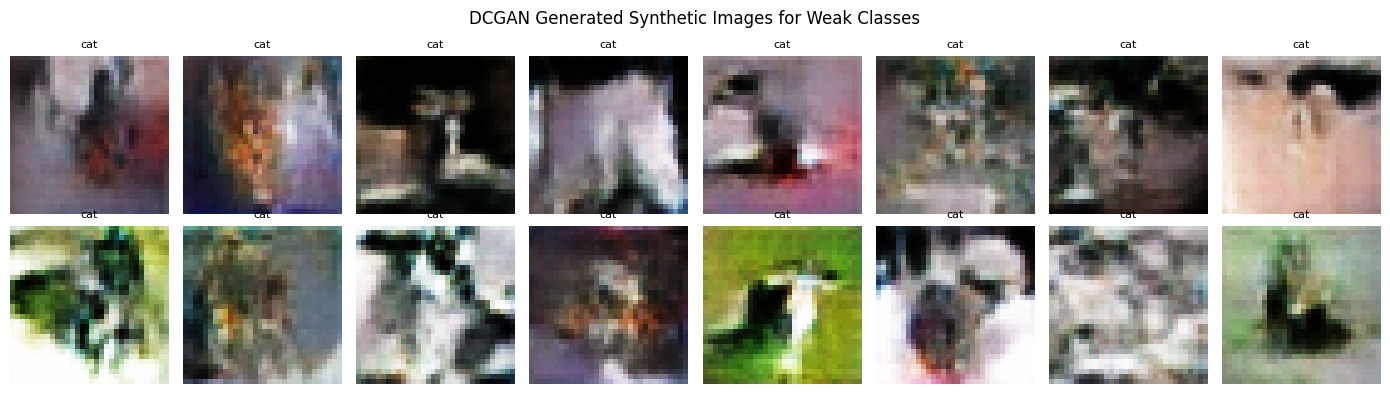

Generated 2000 synthetic images total


In [21]:
def generate_synthetic(generator, n_per_class, weak_classes):
    generator.eval()
    all_images, all_labels = [], []
    with torch.no_grad():
        for cls in weak_classes:
            noise = torch.randn(n_per_class, LATENT_DIM, 1, 1).to(device)
            imgs  = generator(noise).cpu()
            all_images.append(imgs)
            all_labels += [cls] * n_per_class
    return torch.cat(all_images), torch.tensor(all_labels)

syn_images, syn_labels = generate_synthetic(generator, N_SYNTHETIC, WEAK_CLASSES)

# Visualize 16 samples
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    img = syn_images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    ax.imshow(img)
    ax.set_title(CIFAR_CLASSES[syn_labels[i].item()], fontsize=8)
    ax.axis('off')
plt.suptitle('DCGAN Generated Synthetic Images for Weak Classes', fontsize=12)
plt.tight_layout()
plt.show()
print(f"Generated {len(syn_images)} synthetic images total")

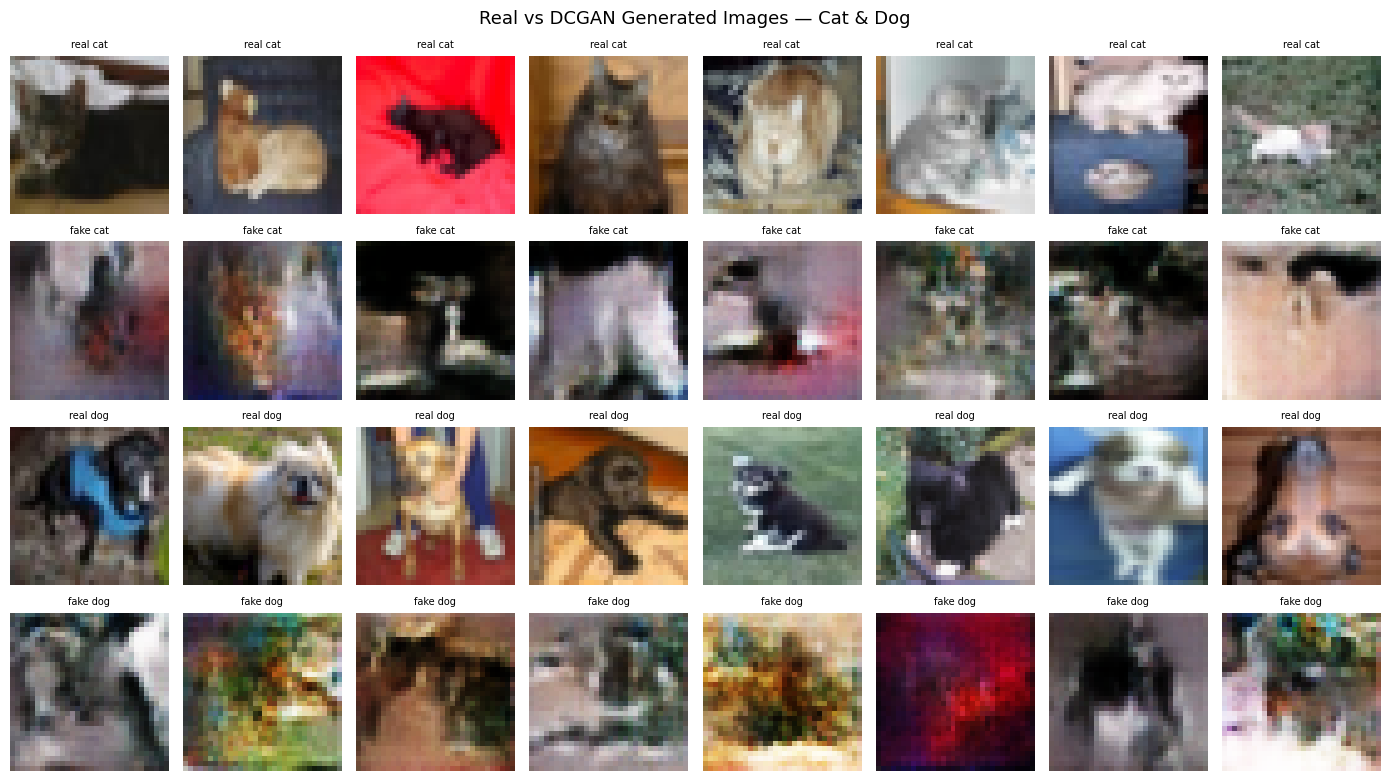

In [25]:
fig, axes = plt.subplots(4, 8, figsize=(14, 8))

# Row 0: real cats
for i in range(8):
    img = cat_imgs[i][0].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    axes[0][i].imshow(img)
    axes[0][i].set_title('real cat', fontsize=7)
    axes[0][i].axis('off')

# Row 1: generated cats
for i in range(8):
    img = syn_images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    axes[1][i].imshow(img)
    axes[1][i].set_title('fake cat', fontsize=7)
    axes[1][i].axis('off')

# Row 2: real dogs
for i in range(8):
    img = dog_imgs[i][0].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    axes[2][i].imshow(img)
    axes[2][i].set_title('real dog', fontsize=7)
    axes[2][i].axis('off')

# Row 3: generated dogs
for i in range(8):
    img = syn_images[N_SYNTHETIC + i].permute(1, 2, 0).numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)
    axes[3][i].imshow(img)
    axes[3][i].set_title('fake dog', fontsize=7)
    axes[3][i].axis('off')

plt.suptitle('Real vs DCGAN Generated Images — Cat & Dog', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
# Convert dataset
def dataset_to_tensors(dataset):
    images, labels = [], []
    for img, label in dataset:
        images.append(img)
        labels.append(label)
    return torch.stack(images), torch.tensor(labels)

print("Converting dataset...")
orig_images, orig_labels = dataset_to_tensors(imbalanced_trainset)

combined_dataset = TensorDataset(
    torch.cat([orig_images, syn_images]),
    torch.cat([orig_labels, syn_labels])
)
expanded_loader = DataLoader(combined_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Fine-tune FROM baseline instead of training from scratch
import copy
retrained_model = copy.deepcopy(baseline_model)  # ← KEY CHANGE
print(f"Expanded dataset: {len(combined_dataset)} samples")
print(f"  Original: {len(orig_images)} | Synthetic added: {len(syn_images)}")
print("\nFine-tuning from baseline model...\n")

# Use lower LR for fine-tuning so we don't forget what baseline learned
retrained_model = train_cnn(retrained_model, expanded_loader, 10, lr=1e-4)

Converting dataset...
Expanded dataset: 43000 samples
  Original: 41000 | Synthetic added: 2000

Fine-tuning from baseline model...

Epoch 1/10 — Loss: 0.246 | Acc: 91.4%
Epoch 2/10 — Loss: 0.209 | Acc: 92.4%
Epoch 3/10 — Loss: 0.186 | Acc: 93.0%
Epoch 4/10 — Loss: 0.176 | Acc: 93.2%
Epoch 5/10 — Loss: 0.166 | Acc: 93.6%
Epoch 6/10 — Loss: 0.154 | Acc: 94.1%
Epoch 7/10 — Loss: 0.147 | Acc: 94.2%
Epoch 8/10 — Loss: 0.143 | Acc: 94.3%
Epoch 9/10 — Loss: 0.135 | Acc: 94.6%
Epoch 10/10 — Loss: 0.130 | Acc: 94.7%



Class            Baseline  Retrained     Change
airplane            79.1%      85.9%      +6.8%
automobile          88.6%      90.5%      +1.9%
bird                74.5%      78.6%      +4.1%
cat                 16.5%      33.2%     +16.7% ←
deer                77.8%      82.0%      +4.2%
dog                 31.5%      37.2%      +5.7% ←
frog                89.5%      88.8%      -0.7%
horse               91.3%      86.2%      -5.1%
ship                89.9%      89.5%      -0.4%
truck               85.9%      86.9%      +1.0%
Overall             72.5%      75.9%      +3.4%


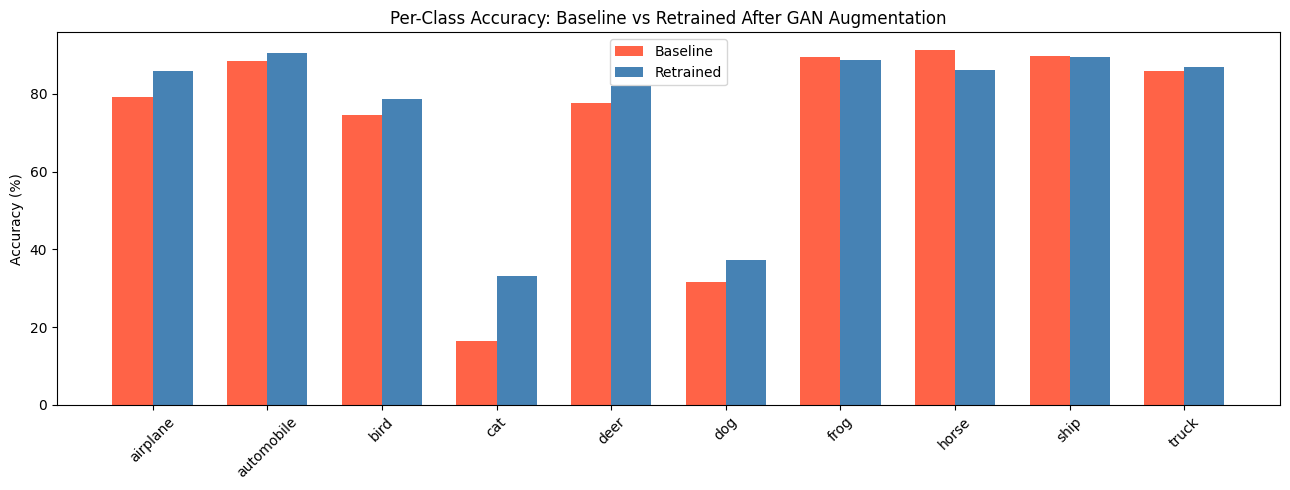

In [23]:
retrained_acc = evaluate_per_class(retrained_model, testloader)

print(f"\n{'Class':<14} {'Baseline':>10} {'Retrained':>10} {'Change':>10}")
print("=" * 50)
for i in range(10):
    b     = baseline_acc[i]
    r     = retrained_acc[i]
    delta = r - b
    flag  = ' ←' if i in WEAK_CLASSES else ''
    print(f"{CIFAR_CLASSES[i]:<14} {b:>9.1f}% {r:>9.1f}% {delta:>+9.1f}%{flag}")

print("=" * 50)
b_mean = np.mean(list(baseline_acc.values()))
r_mean = np.mean(list(retrained_acc.values()))
print(f"{'Overall':<14} {b_mean:>9.1f}% {r_mean:>9.1f}% {r_mean-b_mean:>+9.1f}%")

# Bar chart
x     = np.arange(10)
width = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, [baseline_acc[i]  for i in range(10)], width, label='Baseline',  color='tomato')
ax.bar(x + width/2, [retrained_acc[i] for i in range(10)], width, label='Retrained', color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels(CIFAR_CLASSES, rotation=45)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy: Baseline vs Retrained After GAN Augmentation')
ax.legend()
plt.tight_layout()
plt.show()